# The Anglo-Saxon Exception: Inequality Across Developed Economies

## Introduction

This blog post examines trends in income inequality across developed economies 
since the 1980s, with a particular focus on whether English-speaking nations 
have followed a different path to their continental European counterparts.

We use data from the World Inequality Database (WID) and the OECD to compare 
Gini coefficients and income shares across a selection of countries including 
the US, UK, Germany, France, Sweden, and Canada.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import requests
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")


Libraries loaded successfully


## Data Collection

We collect Gini coefficient data from the OECD Income Distribution Database, 
covering a selection of developed economies from 1980 to present.

In [2]:
import pandas as pd
import requests

# Define our country selection
countries = ['USA', 'GBR', 'DEU', 'FRA', 'SWE', 'CAN', 'AUS', 'NOR', 'DNK']

# Pull Gini coefficient data from OECD API
url = "https://stats.oecd.org/SDMX-JSON/data/IDD/{}..GINI.../all?startTime=1980&endTime=2023".format("+".join(countries))

response = requests.get(url)
print("Status code:", response.status_code)
print("Response received")

Status code: 404
Response received


In [3]:
import pandas as pd

# Load the raw data
df = pd.read_csv('../data/raw/oecd_gini.csv')

# First look at the data
print(df.shape)
print(df.head())
print(df.columns.tolist())

(289, 40)
  STRUCTURE                            STRUCTURE_ID  \
0  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
1  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
2  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
3  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
4  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   

                 STRUCTURE_NAME ACTION REF_AREA Reference area FREQ  \
0  Income distribution database      I      SWE         Sweden    A   
1  Income distribution database      I      SWE         Sweden    A   
2  Income distribution database      I      SWE         Sweden    A   
3  Income distribution database      I      SWE         Sweden    A   
4  Income distribution database      I      NOR         Norway    A   

  Frequency of observation        MEASURE                   Measure  ...  \
0                   Annual  INC_DISP_GINI  Gini (disposable income)  ...   
1                   Annual  INC_DISP_GINI  Gini (disposable income)  ...   
2   

In [4]:
import pandas as pd

# Load the raw data
df = pd.read_csv('../data/raw/oecd_gini.csv')

# First look at the data
print(df.shape)
print(df.head())
print(df.columns.tolist())

(289, 40)
  STRUCTURE                            STRUCTURE_ID  \
0  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
1  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
2  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
3  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
4  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   

                 STRUCTURE_NAME ACTION REF_AREA Reference area FREQ  \
0  Income distribution database      I      SWE         Sweden    A   
1  Income distribution database      I      SWE         Sweden    A   
2  Income distribution database      I      SWE         Sweden    A   
3  Income distribution database      I      SWE         Sweden    A   
4  Income distribution database      I      NOR         Norway    A   

  Frequency of observation        MEASURE                   Measure  ...  \
0                   Annual  INC_DISP_GINI  Gini (disposable income)  ...   
1                   Annual  INC_DISP_GINI  Gini (disposable income)  ...   
2   

In [5]:
# Keep only the columns we need
df_clean = df[['REF_AREA', 'Reference area', 'TIME_PERIOD', 'OBS_VALUE']].copy()

# Rename columns to something cleaner
df_clean.columns = ['country_code', 'country', 'year', 'gini']

# Convert year and gini to numeric
df_clean['year'] = pd.to_numeric(df_clean['year'], errors='coerce')
df_clean['gini'] = pd.to_numeric(df_clean['gini'], errors='coerce')

# Drop any missing values
df_clean = df_clean.dropna()

# Check the result
print(df_clean.shape)
print(df_clean.head(10))
print(df_clean['country'].unique())
print(df_clean['year'].min(), "-", df_clean['year'].max())


(289, 4)
  country_code  country  year      gini
0          SWE   Sweden  2000  0.243000
1          SWE   Sweden  1995  0.211000
2          SWE   Sweden  1991  0.209000
3          SWE   Sweden  1983  0.198000
4          NOR   Norway  2011  0.250000
5          DNK  Denmark  2011  0.250500
6          CAN   Canada  2023  0.306000
7          CAN   Canada  1995  0.293375
8          CAN   Canada  1994  0.291138
9          CAN   Canada  1993  0.290296
<StringArray>
[        'Sweden',         'Norway',        'Denmark',         'Canada',
  'United States',        'Germany',         'France',      'Australia',
 'United Kingdom']
Length: 9, dtype: str
1980 - 2023


In [6]:
# Save cleaned data to processed folder
df_clean.to_csv('../data/processed/gini_clean.csv', index=False)
print("Cleaned data saved successfully")

Cleaned data saved successfully


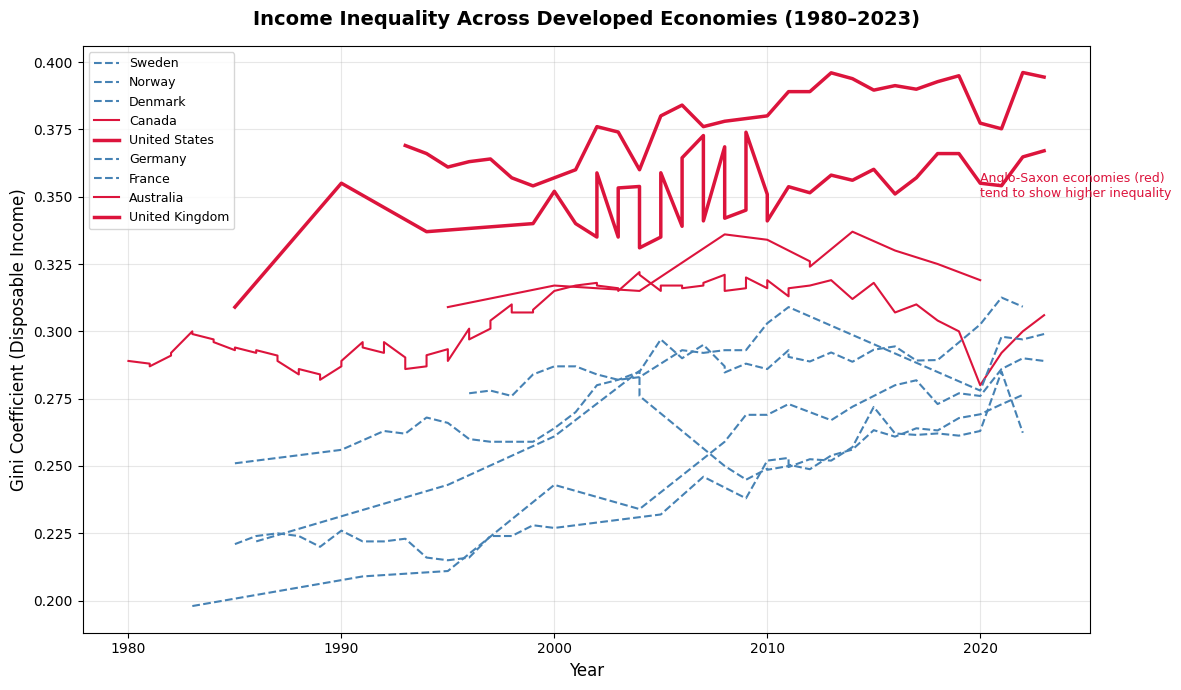

Chart saved!


In [7]:
import matplotlib.pyplot as plt

# Define country groups for colouring
anglo_saxon = ['United States', 'United Kingdom', 'Canada', 'Australia']
continental = ['Germany', 'France', 'Sweden', 'Norway', 'Denmark']

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

for country in df_clean['country'].unique():
    data = df_clean[df_clean['country'] == country].sort_values('year')
    color = 'crimson' if country in anglo_saxon else 'steelblue'
    linewidth = 2.5 if country in ['United States', 'United Kingdom'] else 1.5
    linestyle = '-' if country in anglo_saxon else '--'
    ax.plot(data['year'], data['gini'], 
            label=country, color=color, 
            linewidth=linewidth, linestyle=linestyle)

ax.set_title('Income Inequality Across Developed Economies (1980–2023)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Gini Coefficient (Disposable Income)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# Add annotation
ax.annotate('Anglo-Saxon economies (red)\ntend to show higher inequality', 
            xy=(2020, 0.35), fontsize=9, color='crimson')

plt.tight_layout()
plt.savefig('../output/figures/gini_trends.png', dpi=150)
plt.show()
print("Chart saved!")

In [8]:
# Check US data specifically
us_data = df_clean[df_clean['country'] == 'United States'].sort_values('year')
print(us_data)

    country_code        country  year      gini
268          USA  United States  1993  0.369000
267          USA  United States  1994  0.366000
266          USA  United States  1995  0.361000
265          USA  United States  1996  0.363000
264          USA  United States  1997  0.364000
263          USA  United States  1998  0.357000
262          USA  United States  1999  0.354000
261          USA  United States  2000  0.357000
260          USA  United States  2001  0.360000
259          USA  United States  2002  0.376000
258          USA  United States  2003  0.374000
257          USA  United States  2004  0.360000
256          USA  United States  2005  0.380000
255          USA  United States  2006  0.384000
254          USA  United States  2007  0.376000
253          USA  United States  2008  0.378000
252          USA  United States  2009  0.379000
251          USA  United States  2010  0.380000
250          USA  United States  2011  0.389000
249          USA  United States  2012  0

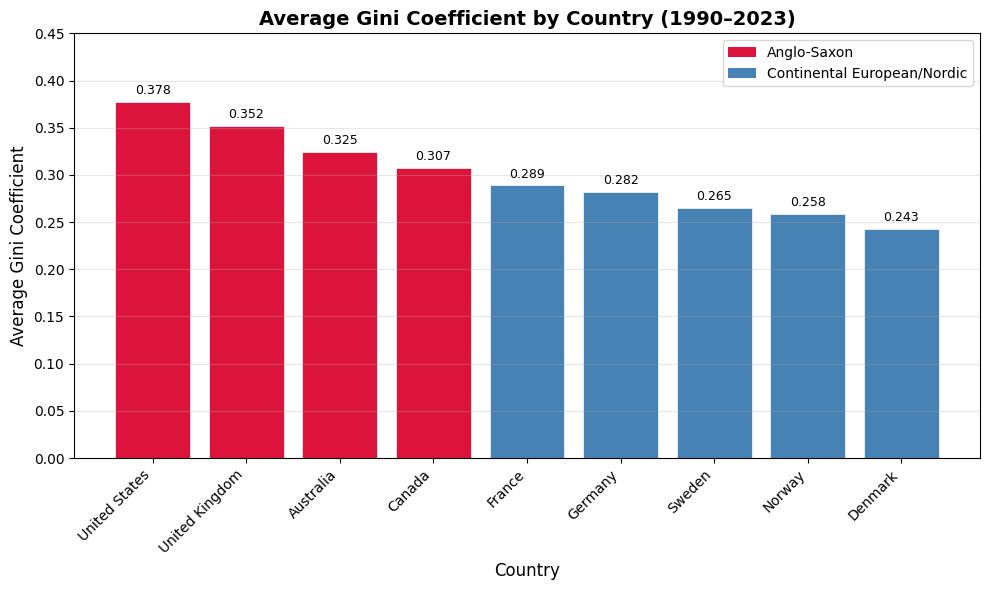

Chart saved!


In [9]:
# Average Gini by country (post-1990 for fair comparison)
avg_gini = df_clean[df_clean['year'] >= 1990].groupby('country')['gini'].mean().sort_values(ascending=False)

# Define colours
colors = ['crimson' if c in anglo_saxon else 'steelblue' for c in avg_gini.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(avg_gini.index, avg_gini.values, color=colors, edgecolor='white', linewidth=0.5)

ax.set_title('Average Gini Coefficient by Country (1990–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Average Gini Coefficient', fontsize=12)
ax.set_ylim(0, 0.45)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, avg_gini.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='crimson', label='Anglo-Saxon'),
                   Patch(facecolor='steelblue', label='Continental European/Nordic')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('../output/figures/gini_average.png', dpi=150)
plt.show()
print("Chart saved!")

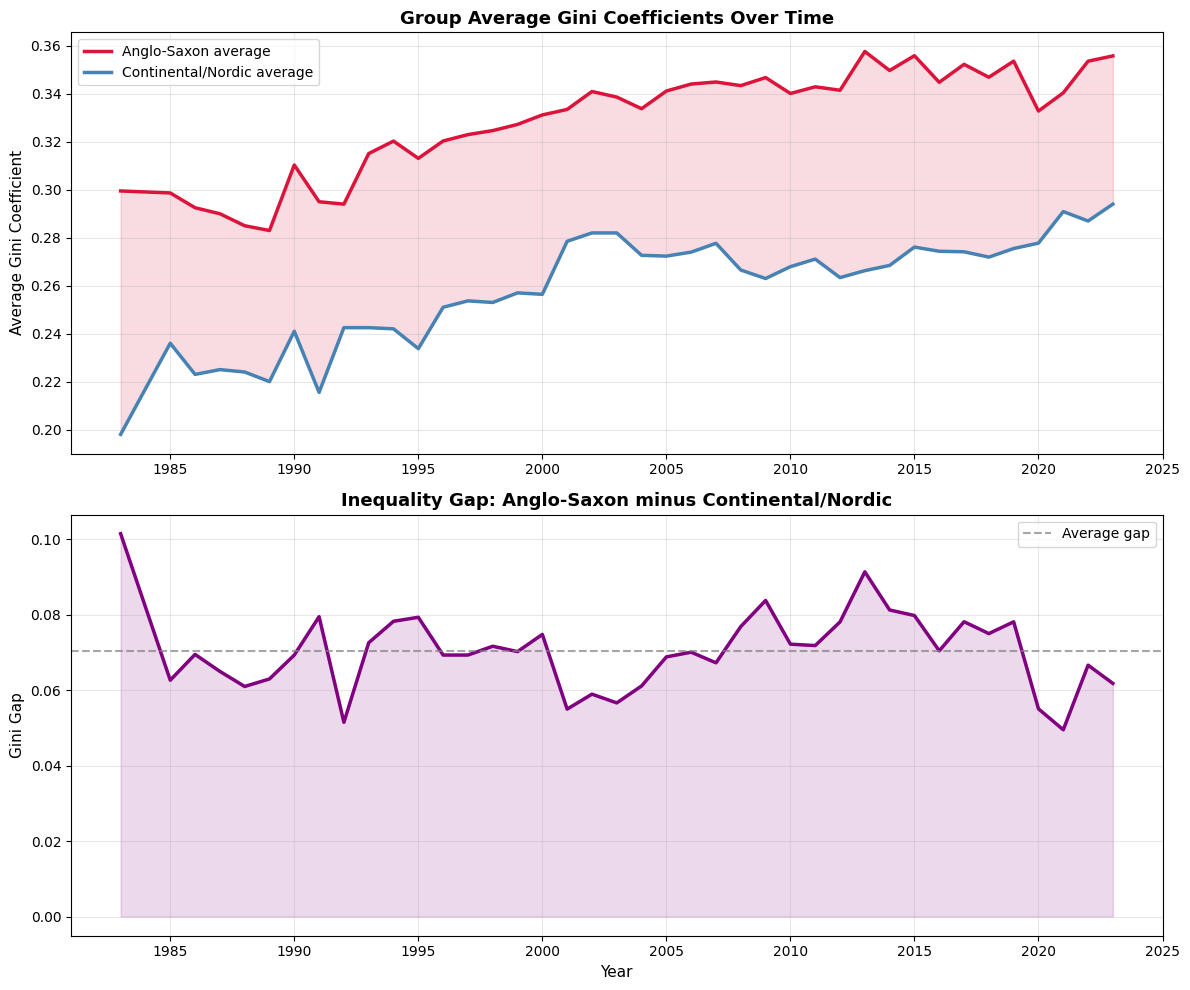

Chart saved!


In [10]:
# Calculate average Gini for each group per year
df_clean['group'] = df_clean['country'].apply(
    lambda x: 'Anglo-Saxon' if x in anglo_saxon else 'Continental/Nordic'
)

group_avg = df_clean.groupby(['year', 'group'])['gini'].mean().reset_index()

anglo_data = group_avg[group_avg['group'] == 'Anglo-Saxon'].sort_values('year')
continental_data = group_avg[group_avg['group'] == 'Continental/Nordic'].sort_values('year')

# Merge to get only years where both groups have data
merged = anglo_data.merge(continental_data, on='year', suffixes=('_anglo', '_continental'))
merged['gap'] = merged['gini_anglo'] - merged['gini_continental']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top chart - use merged data so both series have same length
ax1.plot(merged['year'], merged['gini_anglo'],
         color='crimson', linewidth=2.5, label='Anglo-Saxon average')
ax1.plot(merged['year'], merged['gini_continental'],
         color='steelblue', linewidth=2.5, label='Continental/Nordic average')
ax1.fill_between(merged['year'], merged['gini_anglo'], merged['gini_continental'],
                 alpha=0.15, color='crimson')
ax1.set_title('Group Average Gini Coefficients Over Time', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Gini Coefficient', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom chart - the gap over time
ax2.plot(merged['year'], merged['gap'], color='purple', linewidth=2.5)
ax2.axhline(y=merged['gap'].mean(), color='gray', linestyle='--', alpha=0.7, label='Average gap')
ax2.fill_between(merged['year'], merged['gap'], alpha=0.15, color='purple')
ax2.set_title('Inequality Gap: Anglo-Saxon minus Continental/Nordic', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Gini Gap', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/gini_gap.png', dpi=150)
plt.show()
print("Chart saved!")

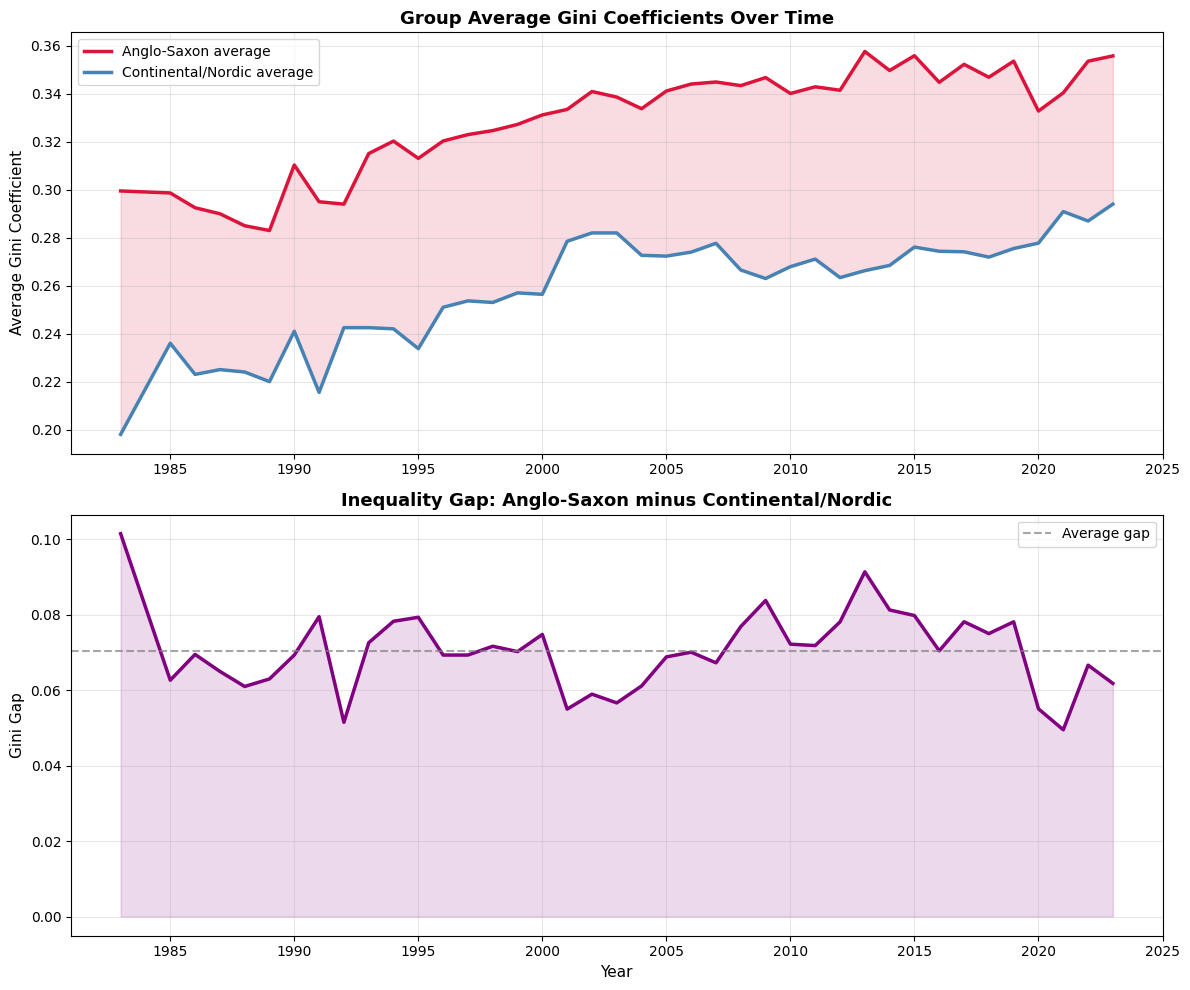

Chart saved!


In [11]:
# Calculate average Gini for each group per year
df_clean['group'] = df_clean['country'].apply(
    lambda x: 'Anglo-Saxon' if x in anglo_saxon else 'Continental/Nordic'
)

group_avg = df_clean.groupby(['year', 'group'])['gini'].mean().reset_index()

anglo_data = group_avg[group_avg['group'] == 'Anglo-Saxon'].sort_values('year')
continental_data = group_avg[group_avg['group'] == 'Continental/Nordic'].sort_values('year')

# Merge to get only years where both groups have data
merged = anglo_data.merge(continental_data, on='year', suffixes=('_anglo', '_continental'))
merged['gap'] = merged['gini_anglo'] - merged['gini_continental']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top chart - use merged data so both series have same years
ax1.plot(merged['year'], merged['gini_anglo'], 
         color='crimson', linewidth=2.5, label='Anglo-Saxon average')
ax1.plot(merged['year'], merged['gini_continental'], 
         color='steelblue', linewidth=2.5, label='Continental/Nordic average')
ax1.fill_between(merged['year'], merged['gini_anglo'], merged['gini_continental'],
                 alpha=0.15, color='crimson')
ax1.set_title('Group Average Gini Coefficients Over Time', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Gini Coefficient', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom chart - the gap over time
ax2.plot(merged['year'], merged['gap'], color='purple', linewidth=2.5)
ax2.axhline(y=merged['gap'].mean(), color='gray', linestyle='--', alpha=0.7, label='Average gap')
ax2.fill_between(merged['year'], merged['gap'], alpha=0.15, color='purple')
ax2.set_title('Inequality Gap: Anglo-Saxon minus Continental/Nordic', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Gini Gap', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/gini_gap.png', dpi=150)
plt.show()
print("Chart saved!")

In [12]:
import wbdata
import datetime

# Define our countries
country_codes = ['USA', 'GBR', 'DEU', 'FRA', 'SWE', 'CAN', 'AUS', 'NOR', 'DNK']

# Define indicators we want from World Bank
indicators = {
    'NY.GDP.PCAP.KD': 'gdp_per_capita',      # GDP per capita (constant USD)
    'NE.TRD.GNFS.ZS': 'trade_openness',       # Trade as % of GDP
    'GC.XPN.TOTL.GD.ZS': 'govt_spending',     # Government expenditure as % of GDP
    'SL.UEM.TOTL.ZS': 'unemployment'          # Unemployment rate
}

# Fetch data
df_wb = wbdata.get_dataframe(indicators, country=country_codes)
df_wb = df_wb.reset_index()
df_wb.columns = ['country', 'date', 'gdp_per_capita', 'trade_openness', 'govt_spending', 'unemployment']

print(df_wb.shape)
print(df_wb.head())

(594, 6)
     country  date  gdp_per_capita  trade_openness  govt_spending  \
0  Australia  2025             NaN             NaN            NaN   
1  Australia  2024    61480.670711       47.145381            NaN   
2  Australia  2023    61869.082499       49.044339            NaN   
3  Australia  2022    61200.458896       45.694642      27.583313   
4  Australia  2021    59465.535671       40.202236      32.551818   

   unemployment  
0         4.090  
1         3.942  
2         3.668  
3         3.728  
4         5.022  


In [13]:
import wbdata
import datetime

# Define our countries
country_codes = ['USA', 'GBR', 'DEU', 'FRA', 'SWE', 'CAN', 'AUS', 'NOR', 'DNK']

# Define indicators we want from World Bank
indicators = {
    'NY.GDP.PCAP.KD': 'gdp_per_capita',      # GDP per capita (constant USD)
    'NE.TRD.GNFS.ZS': 'trade_openness',       # Trade as % of GDP
    'GC.XPN.TOTL.GD.ZS': 'govt_spending',     # Government expenditure as % of GDP
    'SL.UEM.TOTL.ZS': 'unemployment'          # Unemployment rate
}

# Fetch data
df_wb = wbdata.get_dataframe(indicators, country=country_codes)
df_wb = df_wb.reset_index()
df_wb.columns = ['country', 'date', 'gdp_per_capita', 'trade_openness', 'govt_spending', 'unemployment']

print(df_wb.shape)
print(df_wb.head())

(594, 6)
     country  date  gdp_per_capita  trade_openness  govt_spending  \
0  Australia  2025             NaN             NaN            NaN   
1  Australia  2024    61480.670711       47.145381            NaN   
2  Australia  2023    61869.082499       49.044339            NaN   
3  Australia  2022    61200.458896       45.694642      27.583313   
4  Australia  2021    59465.535671       40.202236      32.551818   

   unemployment  
0         4.090  
1         3.942  
2         3.668  
3         3.728  
4         5.022  


In [14]:
# Clean World Bank data
# Extract year as integer from date
df_wb['year'] = pd.to_numeric(df_wb['date'], errors='coerce').astype('Int64')
df_wb = df_wb.drop(columns=['date'])

# Drop rows with missing year or all NaN values
df_wb = df_wb.dropna(subset=['year'])
df_wb = df_wb[df_wb['year'] >= 1980]

# Map World Bank country names to match our Gini data
country_name_map = {
    'United States': 'United States',
    'United Kingdom': 'United Kingdom',
    'Germany': 'Germany',
    'France': 'France',
    'Sweden': 'Sweden',
    'Canada': 'Canada',
    'Australia': 'Australia',
    'Norway': 'Norway',
    'Denmark': 'Denmark'
}

# Merge with Gini data
df_merged = df_clean.merge(df_wb, on=['country', 'year'], how='inner')
df_merged = df_merged.dropna()

print(df_merged.shape)
print(df_merged.head())
print(df_merged['country'].value_counts())

(254, 9)
  country_code  country  year    gini               group  gdp_per_capita  \
0          SWE   Sweden  2000  0.2430  Continental/Nordic    41561.774764   
1          SWE   Sweden  1995  0.2110  Continental/Nordic    35064.413880   
2          SWE   Sweden  1991  0.2090  Continental/Nordic    34268.974400   
4          NOR   Norway  2011  0.2500  Continental/Nordic    72660.675412   
5          DNK  Denmark  2011  0.2505  Continental/Nordic    51667.531321   

   trade_openness  govt_spending  unemployment  
0       81.472159      34.525724         5.466  
1       68.681084      42.626083         8.897  
2       51.170227      36.681253         3.243  
4       69.598734      34.141788         3.196  
5      102.012930      41.355377         7.769  
country
Canada            54
United Kingdom    35
Germany           33
United States     31
Denmark           29
Norway            23
France            20
Sweden            18
Australia         11
Name: count, dtype: int64


In [15]:
import statsmodels.api as sm

# Prepare regression variables
# We'll regress Gini on our economic variables plus an Anglo-Saxon dummy
df_reg = df_merged.copy()

# Create Anglo-Saxon dummy variable (1 = Anglo-Saxon, 0 = Continental/Nordic)
df_reg['anglo_dummy'] = df_reg['country'].apply(
    lambda x: 1 if x in anglo_saxon else 0
)

# Log transform GDP per capita (standard in economics)
import numpy as np
df_reg['log_gdp'] = np.log(df_reg['gdp_per_capita'])

# Define dependent and independent variables
y = df_reg['gini']
X = df_reg[['anglo_dummy', 'log_gdp', 'trade_openness', 'govt_spending', 'unemployment']]
X = sm.add_constant(X)

# Run OLS regression
model = sm.OLS(y, X).fit()

# Print results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.717
Method:                 Least Squares   F-statistic:                     129.4
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           5.01e-67
Time:                        12:08:49   Log-Likelihood:                 592.23
No. Observations:                 254   AIC:                            -1172.
Df Residuals:                     248   BIC:                            -1151.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2107      0.105      2.

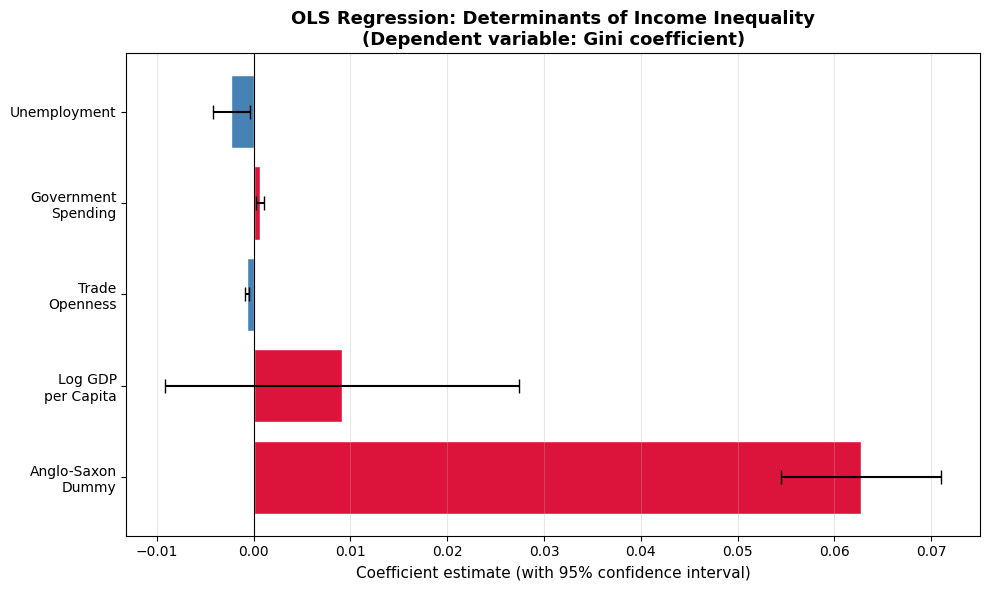

Chart saved!


In [16]:
# Visualise regression coefficients
fig, ax = plt.subplots(figsize=(10, 6))

# Get coefficients and confidence intervals (excluding constant)
coefs = model.params[1:]
conf_int = model.conf_int().iloc[1:]

lower_err = coefs.values - conf_int.iloc[:, 0].values
upper_err = conf_int.iloc[:, 1].values - coefs.values

colors_coef = ['crimson' if c > 0 else 'steelblue' for c in coefs.values]

labels = ['Anglo-Saxon\nDummy', 'Log GDP\nper Capita', 
          'Trade\nOpenness', 'Government\nSpending', 'Unemployment']

ax.barh(labels, coefs.values, 
        xerr=[lower_err, upper_err],
        color=colors_coef, edgecolor='white', capsize=5)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('OLS Regression: Determinants of Income Inequality\n(Dependent variable: Gini coefficient)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient estimate (with 95% confidence interval)', fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/regression_coefficients.png', dpi=150)
plt.show()
print("Chart saved!")

In [17]:
# Summary statistics table by country
countries_list = df_clean['country'].unique()

rows = []
for country in countries_list:
    country_data = df_clean[df_clean['country'] == country].sort_values('year')
    latest_year = country_data['year'].max()
    latest_gini = country_data[country_data['year'] == latest_year]['gini'].values[0]
    avg_gini = country_data[country_data['year'] >= 1990]['gini'].mean()
    earliest_post1990 = country_data[country_data['year'] >= 1990]['gini'].iloc[0]
    change = latest_gini - earliest_post1990
    group = 'Anglo-Saxon' if country in anglo_saxon else 'Continental/Nordic'
    
    rows.append({
        'Country': country,
        'Group': group,
        'Latest Year': latest_year,
        'Latest Gini': round(latest_gini, 3),
        'Avg Gini (1990-2023)': round(avg_gini, 3),
        'Change since 1990': round(change, 3)
    })

summary = pd.DataFrame(rows).sort_values('Avg Gini (1990-2023)', ascending=False)
summary = summary.set_index('Country')
print(summary.to_string())

                             Group  Latest Year  Latest Gini  Avg Gini (1990-2023)  Change since 1990
Country                                                                                              
United States          Anglo-Saxon         2023        0.394                 0.378              0.025
United Kingdom         Anglo-Saxon         2023        0.367                 0.352              0.012
Australia              Anglo-Saxon         2020        0.319                 0.325              0.010
Canada                 Anglo-Saxon         2023        0.306                 0.307              0.019
France          Continental/Nordic         2023        0.299                 0.289              0.022
Germany         Continental/Nordic         2022        0.309                 0.282              0.053
Sweden          Continental/Nordic         2023        0.289                 0.265              0.080
Norway          Continental/Nordic         2022        0.262                 0.258

In [18]:
# Save summary table
summary.to_csv('../data/processed/summary_table.csv')
print("Summary table saved!")

Summary table saved!


# The Anglo-Saxon Exception: Inequality Across Developed Economies

## Introduction

Why is it that people working the same job in London and Copenhagen live such different economic lives? The answer, at least in part, lies in how income is distributed unequally across society, and the data suggest that English-speaking economies have consistently followed a more unequal path than their continental European and Scandinavian peers.

To measure this, economists use the Gini coefficient, a number between 0 and 1 where 0 represents perfect equality (everyone earns the same) and 1 represents perfect inequality (one person holds all the wealth). Most developed nations sit between 0.25 and 0.45, but within that seemingly narrow range lie meaningful differences in living standards, social mobility, and economic opportunity.

Using data from the OECD spanning four decades, this post examines whether the United States, United Kingdom, Canada and Australia have genuinely diverged from Germany, France and the Nordic economies on inequality, and what the data tells us about why.

## Data and Methodology 

The data used in this analysis comes from the OECD Income Distribution Database, one of the most comprehensive and consistently compiled sources of inequality data across developed economies, updated several times a year. 

Nine countries are compared: the United States, the United Kingdom, Australia, and Canada on one side, the four major Anglo-Saxon economies, and France, Germany, Sweden, Norway, and Denmark on the other. These two groups were chosen because they represent broadly comparable levels of economic development, making the differences in inequality between them harder to dismiss as simply a product of wealth.

The measure used throughout is the disposable income Gini coefficient, that is, inequality measured after taxes and government transfers like benefits and pensions. This is the most meaningful measure for comparing what households actually have to live on, and it is standardised across OECD countries, making cross-country comparisons reliable. Data span 1980 to 2023, allowing us to examine how inequality has evolved over four decades. 

## A Tale of Two Worlds

The divergence is stark and immediate. As far back as 1980, Anglo-Saxon economies were already more unequal than their continental peers — and that gap has never closed. The United States leads the rankings throughout the entire period, reaching a Gini coefficient of 0.394 by 2023, compared to just 0.243 in Denmark — a difference of more than 60%.

The roots of this divergence can be traced to the political economy of the 1980s. The simultaneous rise of Thatcherism in the UK and Reaganomics in the US brought sweeping labour market deregulation, declining union membership, and a reorientation toward free market principles. Continental European economies, by contrast, maintained stronger social partnerships between governments, employers and unions, institutions that tend to compress wage inequality from the bottom up.

It is worth noting that inequality has risen across all nine countries since 1980; this is not a story of Anglo-Saxon decline against a stable European backdrop. But the starting points differ dramatically, and those differences have proven remarkably durable.

Looking at average Gini coefficients over the full 1990–2023 period makes the separation even cleaner. Every Anglo-Saxon economy sits above every Continental or Nordic economy without exception. Canada, at 0.307, sits closest to the European group, a reminder that the Anglo-Saxon label covers meaningful variation — but even Canada sits comfortably above France (0.289) and well above Denmark (0.243).

Figure 1: Gini Coefficients Across Developed Economies (1980–2023)


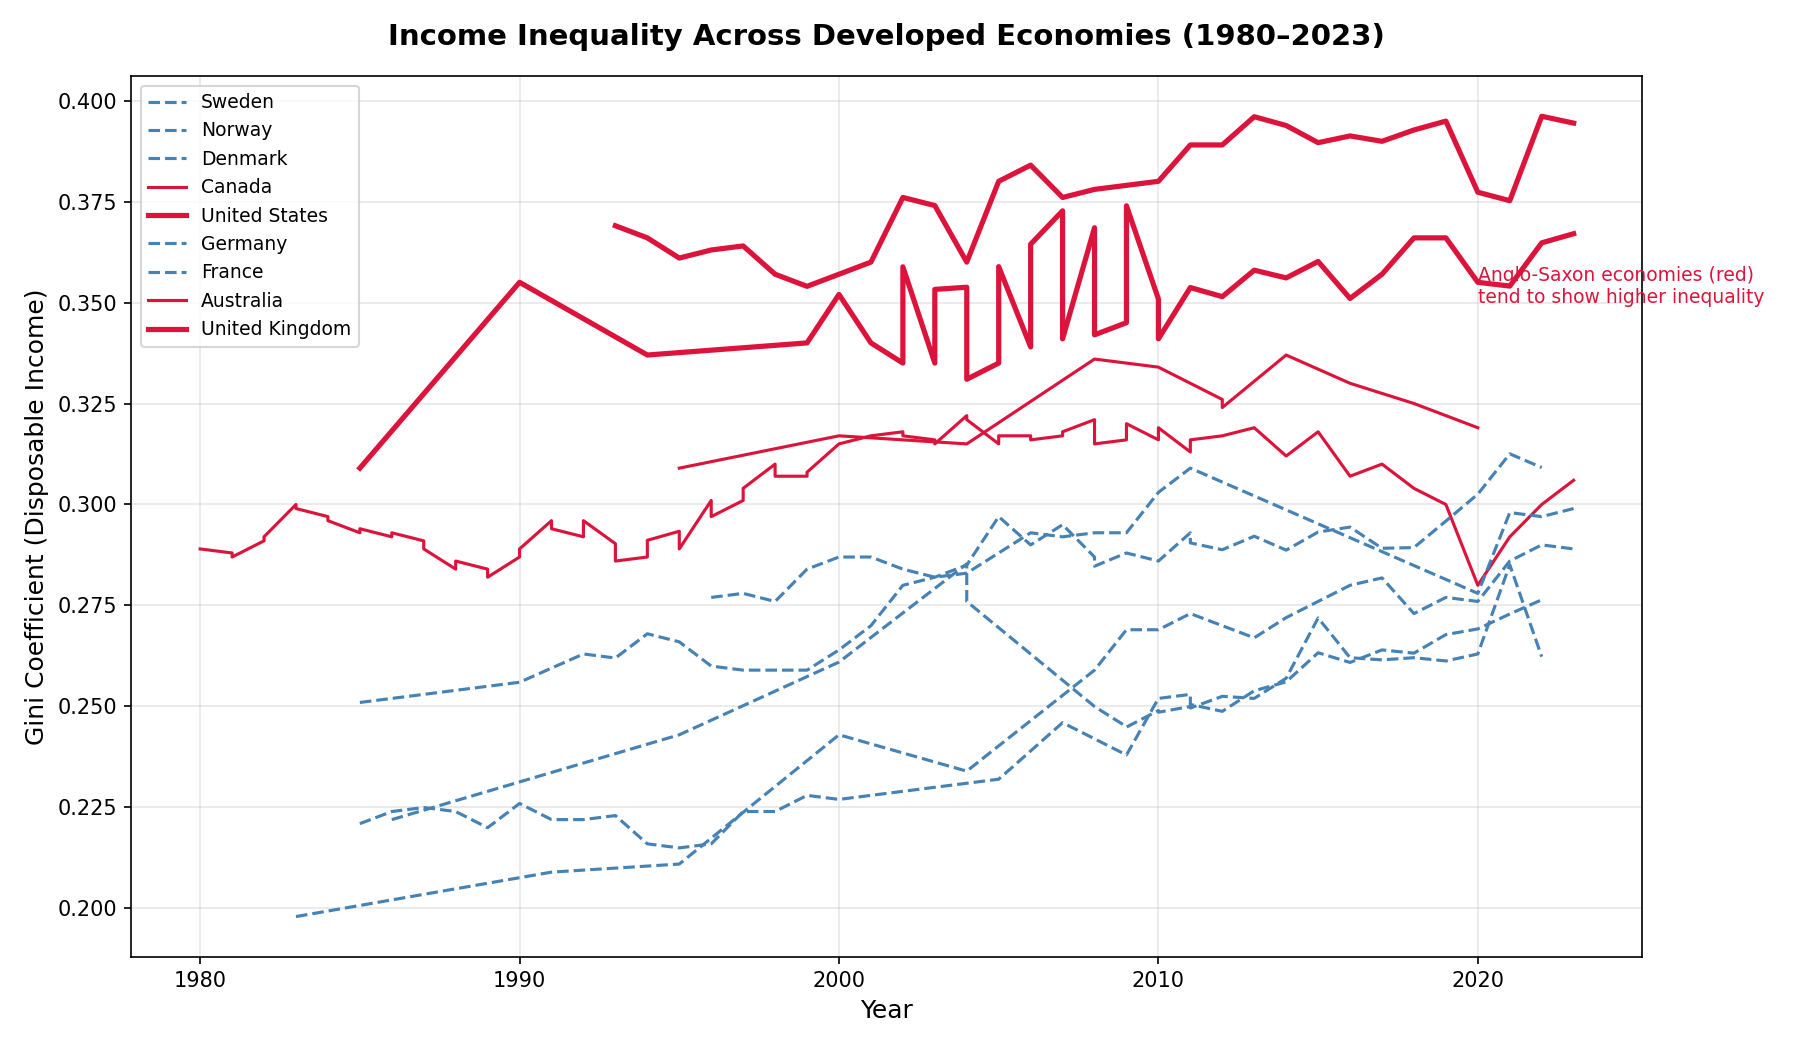


Figure 2: Average Gini Coefficient by Country (1990–2023)


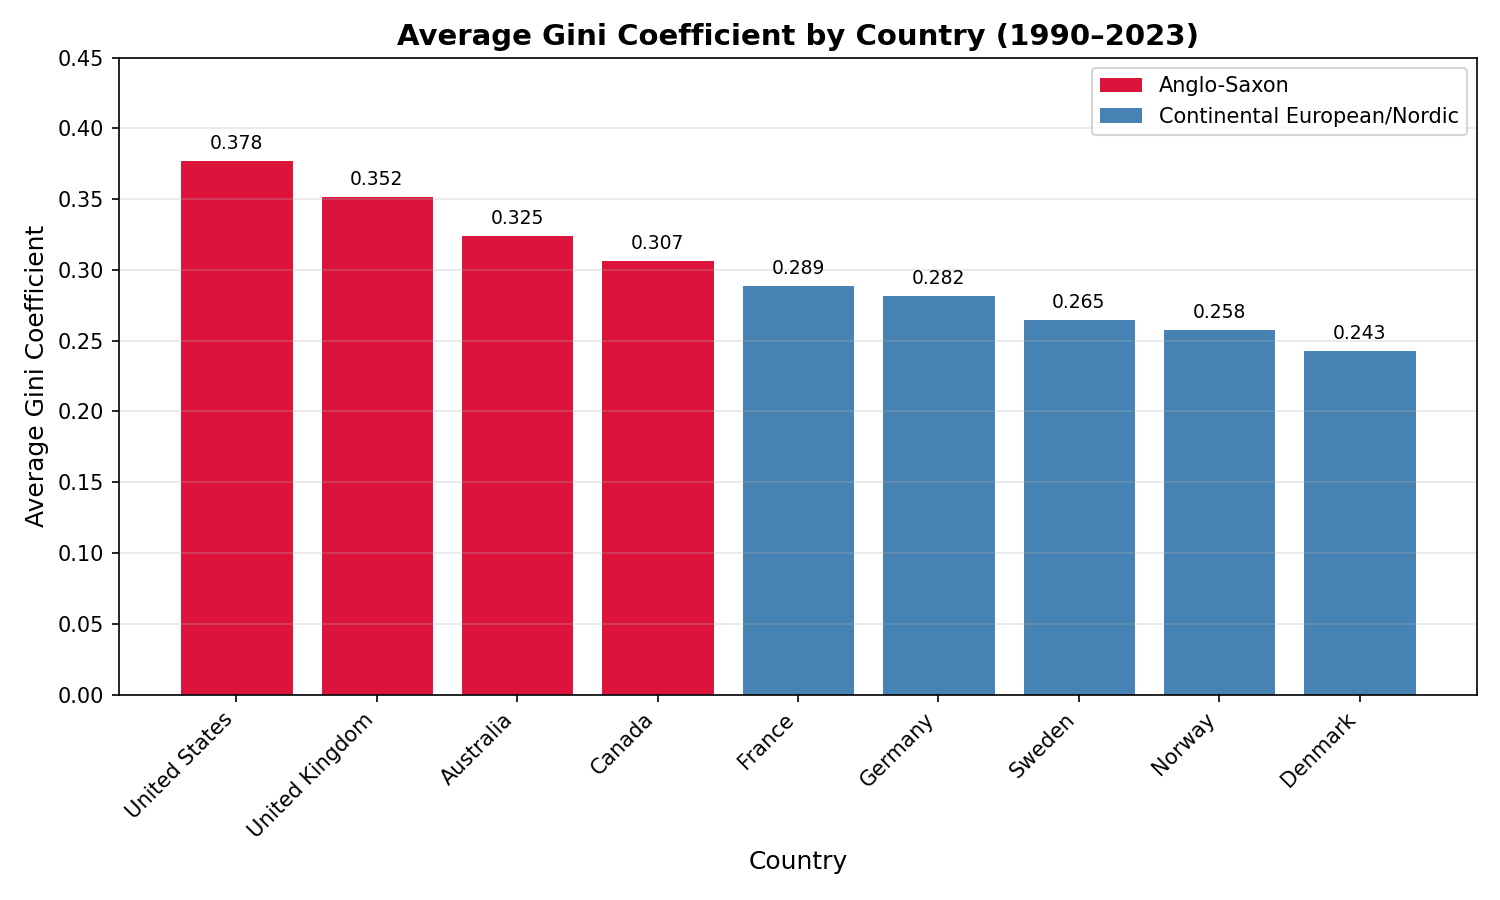

In [19]:
from IPython.display import Image, display

print("Figure 1: Gini Coefficients Across Developed Economies (1980–2023)")
display(Image('../output/figures/gini_trends.png', width=800))

print("\nFigure 2: Average Gini Coefficient by Country (1990–2023)")
display(Image('../output/figures/gini_average.png', width=800))

*Figure 1: Gini coefficients for nine developed economies from 1980 to 2023. Anglo-Saxon economies are shown in red, Continental/Nordic economies in blue.*

*Figure 2: Average Gini coefficient by country over the period 1990–2023, ranked from highest to lowest inequality. The clean separation between the two groups is immediately visible.*

## Persistent but Not Widening

Perhaps the most surprising finding in this analysis is not the size of the inequality gap between Anglo-Saxon and Continental/Nordic economies, but its remarkable stability. As Figure 3 shows, the gap between the two group averages has hovered around 0.07 Gini points for nearly four decades, rarely rising above 0.10 or falling below 0.05. Those expecting a story of runaway Anglo-Saxon inequality pulling ever further away from a stable European baseline will not find it here; both groups have become more unequal, but at broadly similar rates.

This does not mean the picture is static. One notable feature is the sharp dip in Anglo-Saxon inequality around 2020, driven largely by emergency stimulus payments deployed by the US, UK, Canadian and Australian governments during the Covid-19 pandemic. These transfers temporarily boosted incomes at the bottom of the distribution, compressing measured inequality, but the effect proved short-lived, with inequality rebounding sharply by 2022 as support programmes were withdrawn.

Equally interesting is the trajectory of the Nordic economies. Sweden and Denmark, long held up as models of egalitarian distribution, have both seen meaningful increases in inequality since the 1990s. Sweden's Gini rose by 0.080 points since 1990, the largest increase of any country in this sample. This suggests that the Nordic model, while still producing far lower inequality than its Anglo-Saxon counterparts, is not immune to the broader pressures of globalisation and labour market change.

Figure 3: Group Average Gini Coefficients and Inequality Gap Over Time


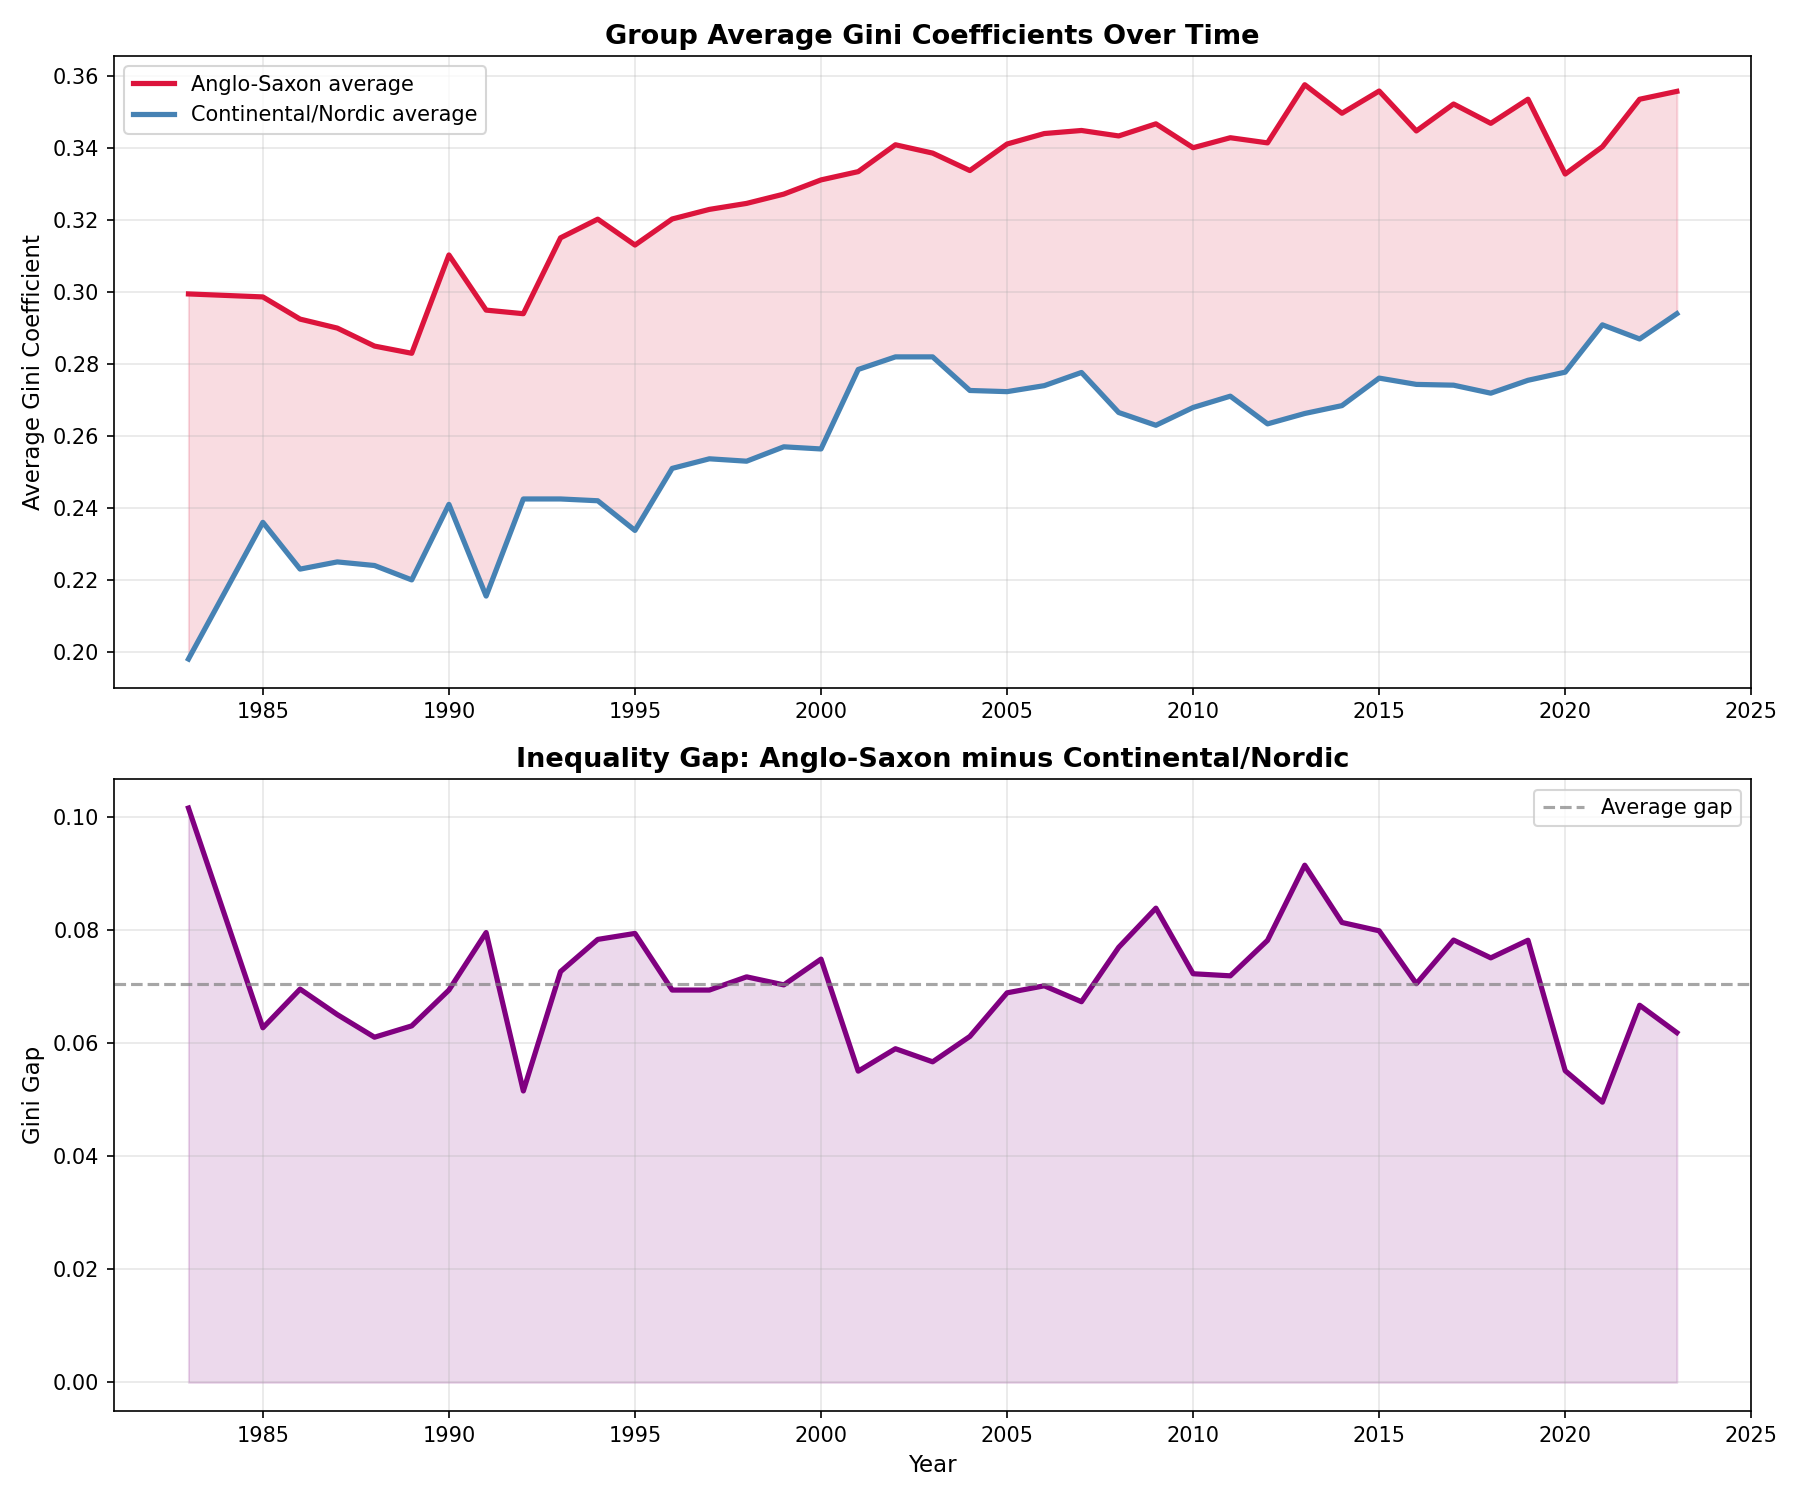

In [20]:
from IPython.display import Image, display

print("Figure 3: Group Average Gini Coefficients and Inequality Gap Over Time")
display(Image('../output/figures/gini_gap.png', width=800))

*Figure 3: (Top) Average Gini coefficients for Anglo-Saxon and Continental/Nordic economies over time, with the gap shaded in red. (Bottom) The absolute gap between the two group averages over time, with the dotted line representing the average gap across the full period.*

## What Drives the Anglo-Saxon Exception?

The regression analysis gets to the heart of the question this post set out to answer. Even after controlling for GDP per capita, trade openness, government spending and unemployment, Anglo-Saxon economies have a Gini coefficient approximately 0.063 higher than their Continental and Nordic counterparts. This coefficient is highly statistically significant, and the model as a whole explains 72% of the variation in Gini coefficients across the sample, a strong result for cross-country economic data.

In plain terms, this means that the Anglo-Saxon inequality premium cannot be explained by standard economic variables. These countries are not more unequal simply because they are richer, more exposed to global trade, or facing higher unemployment. Something more fundamental differentiates them, and it is something the data alone cannot fully capture.

Several structural explanations have been advanced in the economics literature. The sharp decline in trade union membership across the US, UK and Australia from the 1980s onwards weakened the bargaining power of lower-income workers, allowing wage growth to become increasingly concentrated at the top. The growing financialisation of Anglo-Saxon economies, where financial services account for a disproportionate share of output and executive compensation, has further widened the gap between top earners and the rest. Continental European economies, by contrast, have maintained stronger corporatist institutions, formal arrangements between governments, employers and unions, that tend to compress wage inequality structurally rather than relying solely on redistribution.

One counterintuitive finding deserves attention. Government spending shows a small positive association with inequality in this regression, suggesting that higher-spending countries are, if anything, slightly more unequal. This does not mean government spending increases inequality. Rather, it likely reflects reverse causality; countries with higher inequality tend to spend more on redistribution in response to that inequality, but this spending is not always sufficient to fully close the gap. It is a reminder that redistribution treats the symptom rather than the cause.

Figure 4: OLS Regression Coefficients - Determinants of Income Inequality


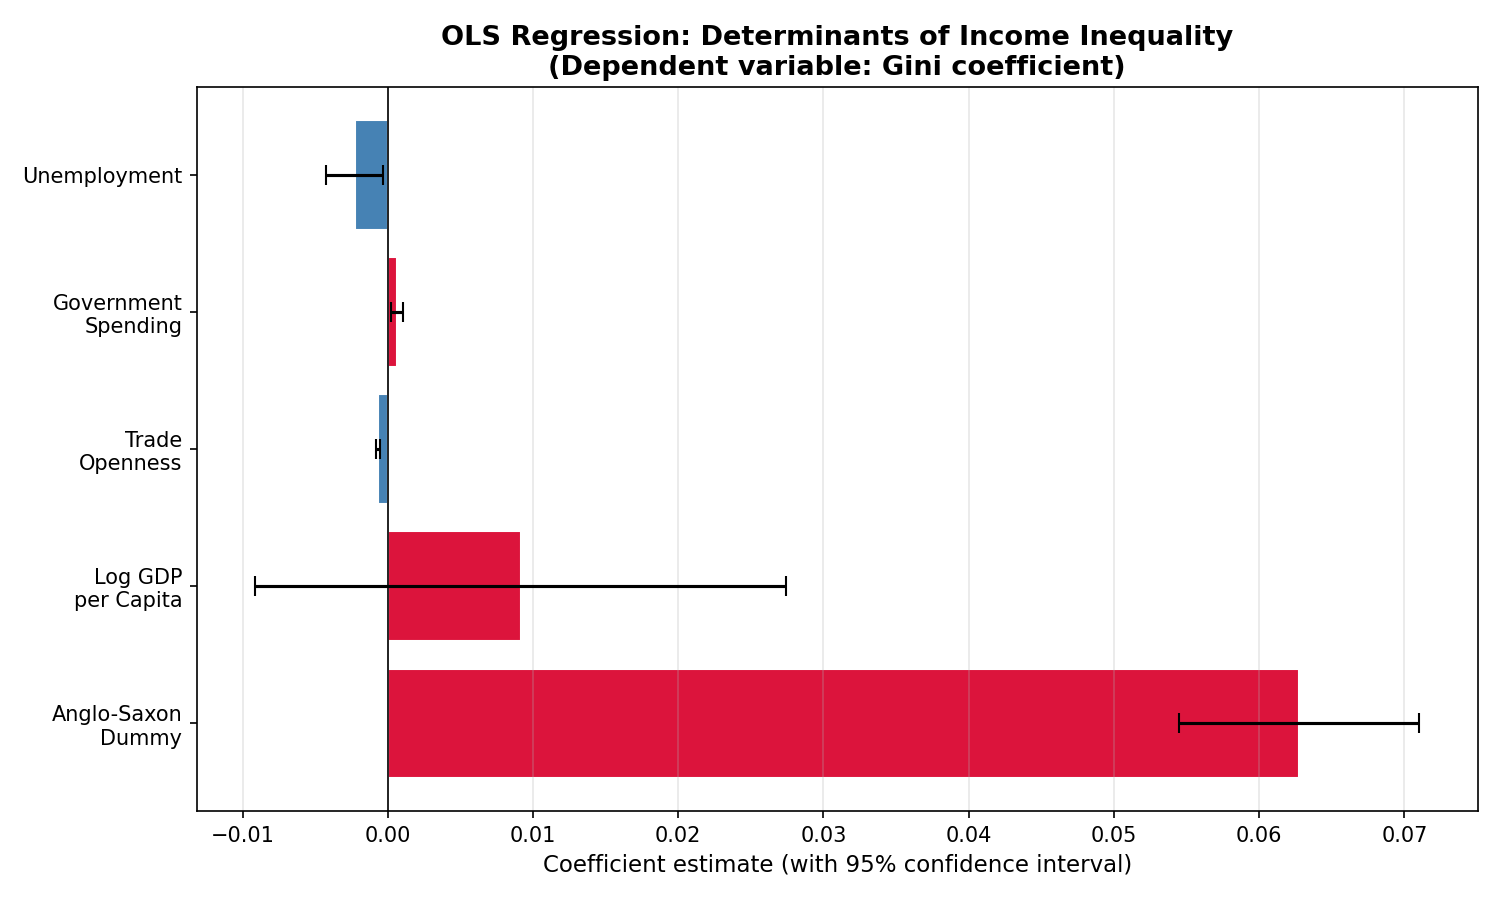

In [21]:
from IPython.display import Image, display

print("Figure 4: OLS Regression Coefficients - Determinants of Income Inequality")
display(Image('../output/figures/regression_coefficients.png', width=800))

*Figure 4: OLS regression coefficient plot showing the estimated effect of each variable on the Gini coefficient, with 95% confidence intervals shown as error bars. 
Red bars indicate a positive association with inequality, blue bars indicate a negative association. Coefficients whose confidence intervals do not cross zero are statistically significant.*

## Conclusion

Four decades of data tell a consistent story. English-speaking economies are meaningfully more unequal than their continental European and Nordic peers, and that gap has proven remarkably resistant to change. The United States sits at the top of the inequality rankings with a Gini coefficient of 0.394, more than 60% higher than Denmark's 0.243 — and this separation holds across every country and almost every year in the sample.

But this analysis also complicates the simple narrative of runaway Anglo-Saxon inequality. The gap between the two groups has not widened dramatically since the 1980s — it has persisted at around 0.07 Gini points, with both groups becoming more unequal at broadly similar rates. Even the Nordic economies, long held up as models of egalitarian distribution, have seen inequality rise — Sweden recorded the largest increase of any country in this sample since 1990. The Anglo-Saxon exception is real, but it exists within a broader story of rising inequality across all developed economies.

Perhaps most striking is what the regression analysis reveals. Even after accounting for differences in GDP, trade exposure, government spending and unemployment, Anglo-Saxon economies carry an inequality premium of approximately 0.063 Gini points. Standard economic variables cannot explain the gap away. The roots of the Anglo-Saxon exception appear to lie in deeper institutional and historical factors — the decline of trade unions, the financialisation of these economies, and welfare state models that redistribute income without fully addressing the structural drivers of wage inequality.

Whether this gap is inevitable is an open question. Some economists argue it reflects a genuine trade-off — that the flexible, dynamic labour markets of Anglo-Saxon economies generate stronger growth and innovation at the cost of higher inequality. Others argue it reflects political choices that could be reversed through stronger labour market institutions, higher minimum wages, and more progressive taxation. What the data cannot tell us is which of these interpretations is correct — but it does tell us, clearly and consistently, that the gap is real, it is large, and four decades on, it shows no sign of closing.

---
*Data: OECD Income Distribution Database and World Bank Development Indicators. Analysis conducted in Python using pandas, statsmodels, and matplotlib. Full replication code available at: 
[github.com/GeorgeKingham/Anglo-Saxon-Inequality](https://github.com/GeorgeKingham/Anglo-Saxon-Inequality)*

![Gini Trends](output/figures/gini_trends.png)